# Plotting with matplotlib

Matplotlib is one of several modules that provide plotting functions for python. It is the most commonly used in mathematics and data science. 

`matplotlib` can do many things, from quick graphs to full-blown graphical user interface and interactive web apps. We focus on the `pyplot` component commonly used to produce mathematical figures. You load pyplot with 
```
import matplotlib.pyplot as plt
```
Just like it is customary to use `np` as the prefix for `numpy`, most people use `plt` instead of `pyplot`.


`matplotlib` can interact with jupyter notebooks (remember that jupyter is only one way to use python) through the *matplotlib magic* and specific drivers. We won;t go into the details. Just remember to add the command `%matplotlib ipympl` or `%matplotlib widget` at the beginning of your notebook. 

matplotlib has tons of documentation at http://matplotlib.org, and many online tutorials.

## figures, axes, etc
Say we want draw the graph of a function $f$ on an inteval $(a,b)$, we can generate a ndarray of `x` values using `np.linspace`, plot point with coordinates $(X, f(X))$ and connect the points with lines. 


Text(0.5, 1.0, 'Our first plot')

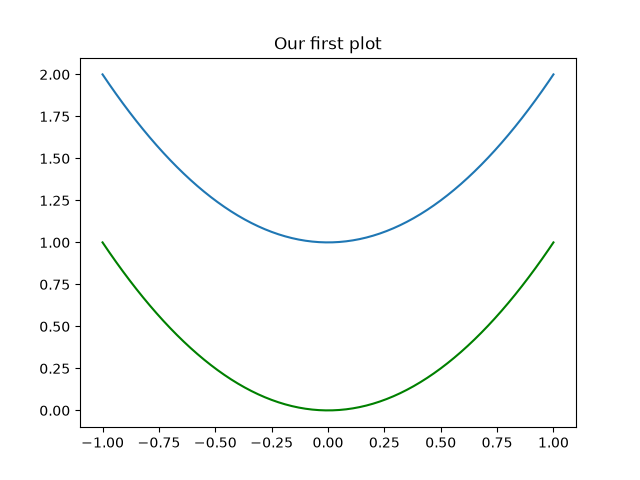

In [2]:
import matplotlib.pyplot as plt
%matplotlib widget
import numpy as np

a = -1
b = 1
def f(x: float) -> float:
    return x**2+1

X = np.linspace(a, b, 201)

fig = plt.figure()
ax  = plt.axes()
p1  = ax.plot(X, f(X))
p2 = ax.plot(X, f(X)-1)
p2[0].set_color('green')
ax.set_title('Our first plot')

Here, we created a *Figure*. Think of a figure as a blank page in which we may want to draw one or several graphs. In matplotlib lingo, each of these graphs are called *Axes*. We created a single Axes object `ax` which fills the whole figure, but a Figure may contain several axes. 

in `ax`, we created a plot, `p1`which is a list of `matplotlib.lines.Line2D` objects. 


The full hierarchy of objects in a figure is shown in this figure from matplotlib documentation
![](https://matplotlib.org/stable/_images/sphx_glr_anatomy_001_2_00x.png)

It gives us some ideas of what we can do to change the appearance of our plot.

In [2]:
t = ax.set_title('A simple plot')
x = ax.set_xlabel(r'$x$')
y = ax.set_ylabel(r'$y$')

def g(x: float) -> float:
    return 2-x**2
p2 = ax.plot(X,g(X))
ax.grid()

Notice that the changes are applied back in the figure we created. This makes sense, we created `fig`, added `ax` to it and are not adding plots of `ax`. It is good practive to *close* the figure once we are done with it. Typically, matplotlib has a 20 open figures limit. 

In [3]:
plt.close(fig)

The process to open a new figure can be shortened a little using `plt.subplot`:

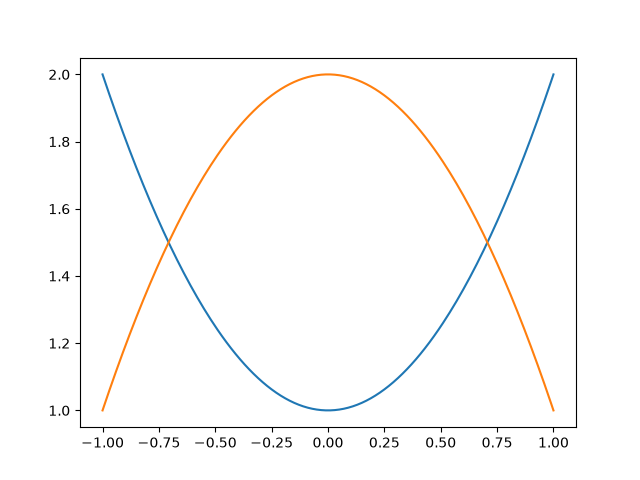

In [4]:
fig, ax = plt.subplots()
p1 = ax.plot(X,f(X))
p2 = ax.plot(X,g(X))

In [5]:
plt.close(fig)

Using `plt.subplots`, we can easily create figures containig several plot (*i.e.* several `Axes`). 

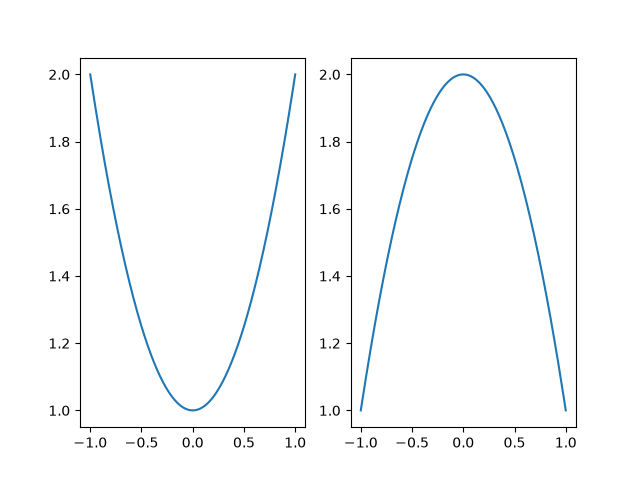

In [6]:
fig, axes = plt.subplots(1, 2)
p1 = axes[0].plot(X,f(X))
p2 = axes[1].plot(X,g(X))

## Some commonly used plotting functions:

* `plt.plot`: 2D line plot
* `plt.scatter`: 2D points cloud
* `plt.bar`: 2D bar plot (vertical)
* `plt.barh`: 2D bar plot (horizontal)
* `plt.imshow`: display a 2D array of numbers (or RGB values) as an image
* `plt.quiver`: draw arrows in 2D

All of these have too many options to list. `help(function)` and `?function` are your friends.

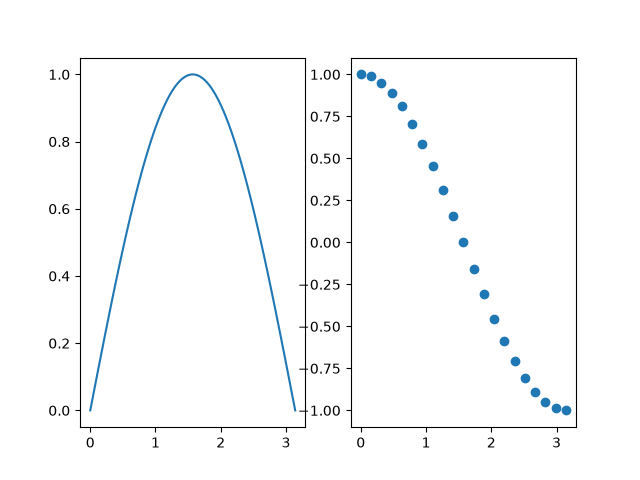

In [7]:
fig, ax = plt.subplots(1, 2)
X = np.linspace(0,np.pi,101)
X1 = np.linspace(0,np.pi,21)

p0 = ax[0].plot(X,np.sin(X))
p1 = ax[1].scatter(X1, np.cos(X1))

In [8]:
plt.close(fig)

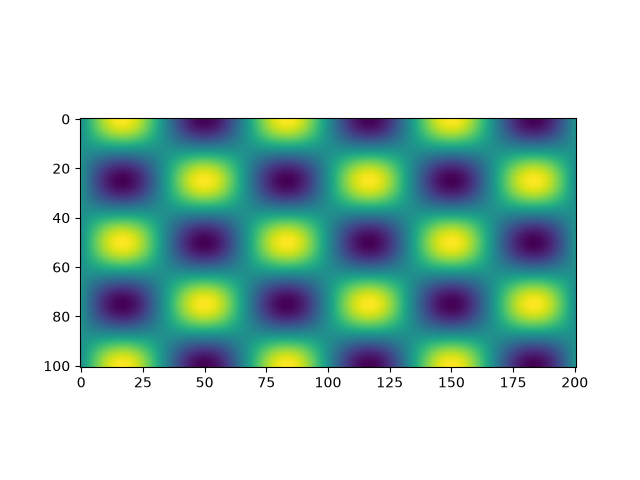

In [9]:
fig, ax = plt.subplots()
nrow = 101
ncol = 201
X = np.linspace(0,2*np.pi, nrow)
Y = np.linspace(0,2*np.pi, ncol)
data2D = np.empty((nrow,ncol))

for i in range(nrow):
    for j in range(ncol):
        data2D[i,j] = np.cos(2*X[i]) * np.sin(3*Y[j])
p1 = ax.imshow(data2D)


In [10]:
plt.close(fig)

## Legends, line styles, etc

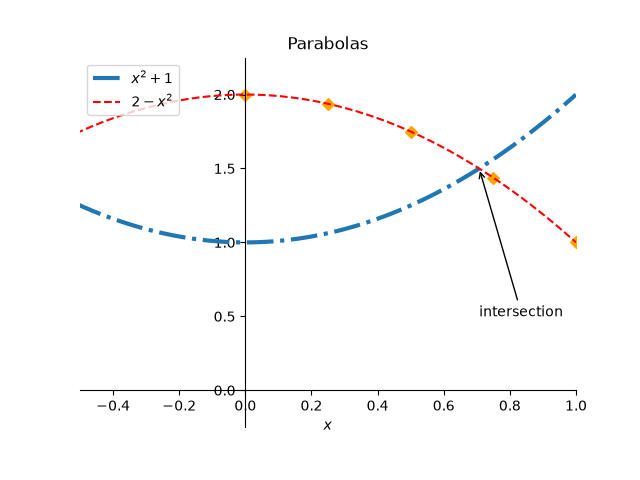

In [11]:
plt.close('all')
def f(x: float) -> float:
    return x**2+1
def g(x: float) -> float:
    return 2-x**2
    
X = np.linspace(-1,1,101)
fig, ax = plt.subplots()
p1 = plt.plot(X,f(X), linewidth=3, label = r'$x^2+1$')
p1[0].set_linestyle('dashdot')
p2 = plt.plot(X,g(X), color = 'red', linestyle = '--', label = r'$2-x^2$')
ax.set_title('Parabolas')
ax.set_xlabel(r'$x$')
ax.set_xlim(-0.5,1)
ax.set_ylim(-0.25,2.25)

ax.spines[['left', 'bottom']].set_position('zero')
ax.spines[['top', 'right']].set_visible(False)
ax.legend(loc='upper left')

X = np.linspace(0,1,5)
p3 = ax.scatter(X,g(X), marker='D', color = 'orange')

x0 = np.sqrt(2)/2
a1 = ax.annotate('intersection', (x0, g(x0)), xytext = (x0,0.5), arrowprops = {'arrowstyle': '->'})

## Illustrating some mathematical concepts
### Tangent line as the limit of the secant line

Text(0, 0.5, '$y$')

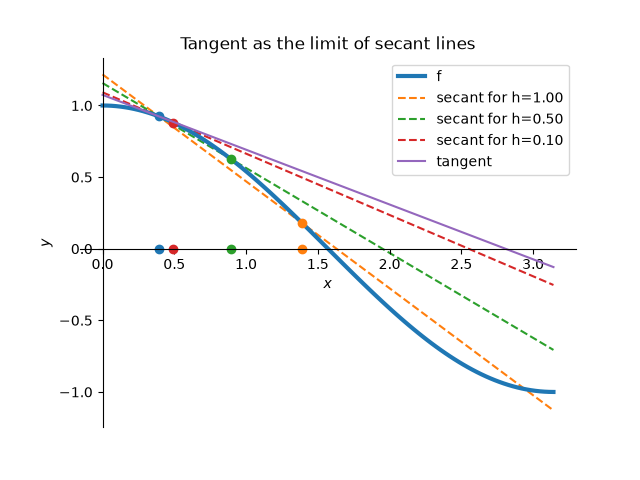

In [12]:
fig, ax = plt.subplots()

# we will start with cos x from 0 to pi
def f(x):
    return np.cos(x)
def fp(x):
    return -np.sin(x)
    
X = np.linspace(0,np.pi, 101) 
ax.plot(X,f(X), linewidth=3,label = 'f')
x0 = np.pi/8
plt.scatter([x0]*2,[0,f(x0)])
for h in [1, 0.5, 0.1]:
    plt.plot(X, f(x0) + (f(x0+h) - f(x0))/h * (X-x0),label = f'secant for h={h:.2f}', linestyle='--',zorder = 0)
    plt.scatter([x0+h]*2, [0,f(x0+h)], marker='o',zorder = 2)
s = ax.plot(X,f(x0) + fp(x0) * (X-x0), label='tangent', linestyle='-')
ax.legend()
ax.spines[['left', 'bottom']].set_position('zero')
ax.spines[['top', 'right']].set_visible(False)
ax.set_title('Tangent as the limit of secant lines')
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$y$')

### Definite integrals and area under the curve

Help on method hlines in module matplotlib.axes._axes:

hlines(
    y,
    xmin,
    xmax,
    colors=None,
    linestyles='solid',
    *,
    label='',
    data=None,
    **kwargs
) method of matplotlib.axes._axes.Axes instance
    Plot horizontal lines at each *y* from *xmin* to *xmax*.

    Parameters
    ----------
    y : float or array-like
        y-indexes where to plot the lines.

    xmin, xmax : float or array-like
        Respective beginning and end of each line. If scalars are
        provided, all lines will have the same length.

    colors : :mpltype:`color` or list of color , default: :rc:`lines.color`

    linestyles : {'solid', 'dashed', 'dashdot', 'dotted'}, default: 'solid'

    label : str, default: ''

    Returns
    -------
    `~matplotlib.collections.LineCollection`

    Other Parameters
    ----------------
    data : indexable object, optional
        If given, the following parameters also accept a string ``s``, which is
        interpreted as ``data[s]``

Text(0, 0.5, '$y$')

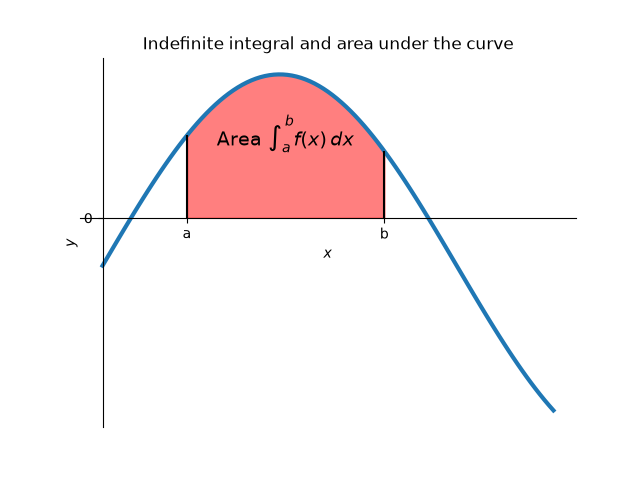

In [3]:
plt.close('all')
fig, ax = plt.subplots()
def f(x):
    return np.sin(x)-0.25
    
a = 0.75
b = 2.5
help(ax.hlines)
X = np.linspace(0,4, 101) 
ax.plot(X,f(X), linewidth=3,label = 'f')

I = np.linspace(a,b,101)
ax.fill_between(I,f(I),color='red', alpha=.5)
ax.vlines([a,b],[0,0], [f(a),f(b)],color='black')
ax.text((a+b)/2, f((a+b)/2)/2,r"Area $\int_a^b f(x)\, dx$", fontsize = 14, horizontalalignment = 'center')
ax.spines[['left', 'bottom']].set_position('zero')
ax.spines[['top', 'right']].set_visible(False)
ax.set_xticks([a,b],['a','b'])
ax.set_yticks([0], [0])
ax.set_title('Indefinite integral and area under the curve')
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$y$')

### Riemann sums

Text(0, 0.5, '$y$')

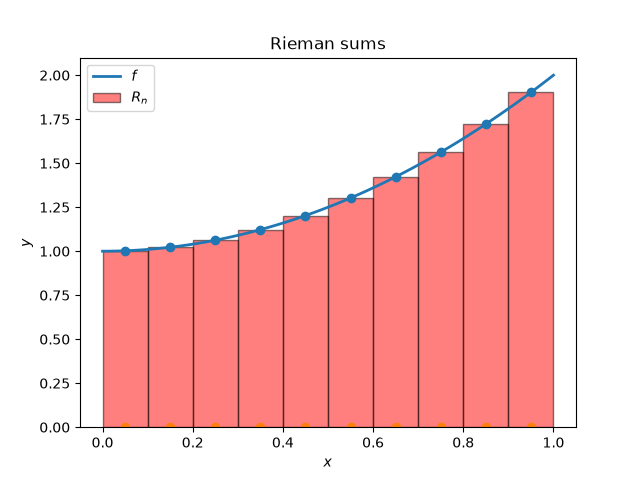

In [14]:
## Rieman summs
def f(x):
    return 1+x**2

fig, ax = plt.subplots()
n = 101
X = np.linspace(0,1,n)
ax.plot(X,f(X),lw=2,label='$f$')

ni = 11
Xi = np.linspace(0,1,ni)
Xis = (Xi[:-1]+Xi[1:])/2
ax.bar(Xi[:-1],f(Xis),width = 1/(ni-1),alpha=0.5,label = '$R_n$', align='edge',edgecolor='k',color='r')
ax.scatter(Xis,f(Xis))
ax.scatter(Xis,np.zeros(np.shape(Xis)))

ax.legend()
ax.set_title('Rieman sums')
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$y$')